In [1]:
# Credit Card Default Prediction – Project Summary

# Objective:
# Predict whether a credit card customer will default on payment using historical billing and payment data.

# Data Preprocessing:
# 1. Encoded categorical variables (default, SEX).
# 2. Applied one-hot encoding for EDUCATION and MARRIAGE.
# 3. Removed the ID column as it has no predictive value.
# 4. Performed basic EDA to understand distributions and class imbalance.

# Feature Engineering:
# 1. Created Total_Bill and Total_Pay from past 6 months data.
# 2. Created Payment_ratio and credit_utilization.
# 3. Calculated avg_payment_delay from payment history.
# 4. Created bill_difference between recent and older bills.

# Model Used:
# XGBoost Classifier was used to capture non-linear relationships in the data.

# Model Performance:
# Accuracy: 0.71
# Default Recall: 0.68
# Default F1-score: 0.51

# Conclusion:
# The model captures customer payment behavior patterns and can identify potential defaulters.
# Improving recall for the default class helps reduce financial risk in credit lending.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data1.csv")
print(df.head())
print(df.info())
print(df.isnull().sum())
print("Shape of the data:",df.shape)

   ID  LIMIT_BAL SEX   EDUCATION MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000   F  University  Married   24      2      2     -1     -1   
1   2     120000   F  University   Single   26     -1      2      0      0   
2   3      90000   F  University   Single   34      0      0      0      0   
3   4      50000   F  University  Married   37      0      0      0      0   
4   5      50000   M  University  Married   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   
3  ...      28314      28959      29547      2000      2019      1200   
4  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default  
0         0         0         0        Y  
1     

In [3]:
# average bill & payment
print("\nAverage bill amount:")
print(df[["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]].mean())

print("\nAverage payment amount:")
print(df[["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]].mean())


Average bill amount:
BILL_AMT1    51223.330900
BILL_AMT2    49179.075167
BILL_AMT3    47013.154800
BILL_AMT4    43262.948967
BILL_AMT5    40311.400967
BILL_AMT6    38871.760400
dtype: float64

Average payment amount:
PAY_AMT1    5663.580500
PAY_AMT2    5921.163500
PAY_AMT3    5225.681500
PAY_AMT4    4826.076867
PAY_AMT5    4799.387633
PAY_AMT6    5215.502567
dtype: float64


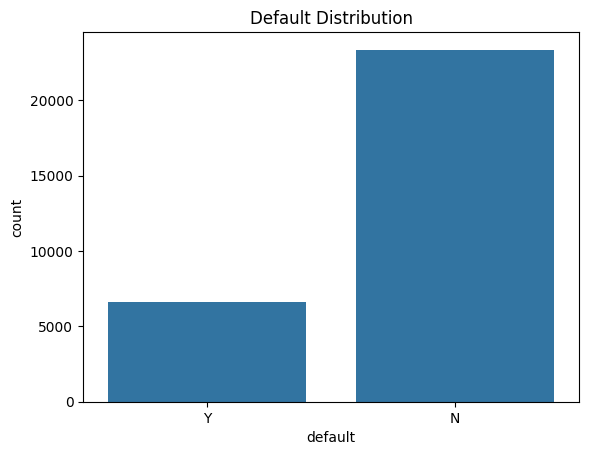

In [4]:
# visualizations
sns.countplot(x="default",data=df)
plt.title("Default Distribution")
plt.show()

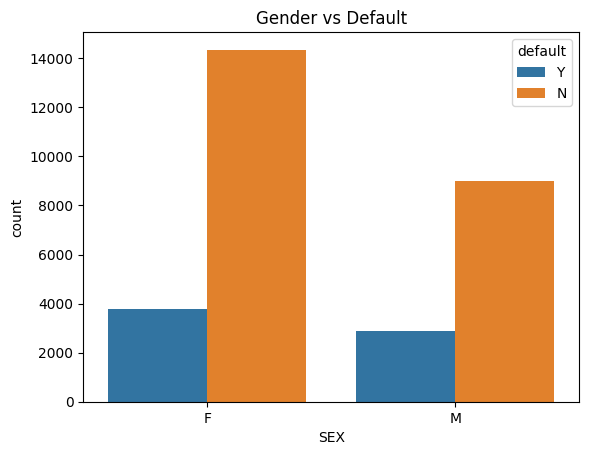

In [5]:
sns.countplot(x="SEX", hue="default", data=df)
plt.title("Gender vs Default")
plt.show()

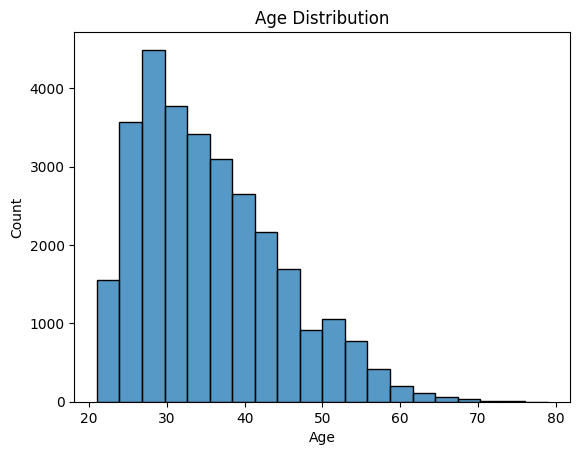

In [6]:
sns.histplot(df["AGE"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

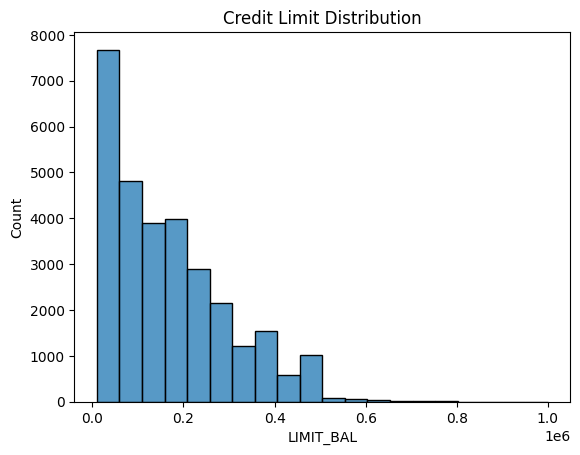

In [7]:
sns.histplot(df["LIMIT_BAL"], bins=20)
plt.title("Credit Limit Distribution")
plt.show()

In [8]:
# Enconding
df["default"] = df["default"].map({"Y":1, "N":0})
df["SEX"] = df["SEX"].map({'F':1 , 'M':0})
df = pd.get_dummies(df, columns=["EDUCATION","MARRIAGE"], drop_first=True)

df.drop("ID", axis=1, inplace=True)

In [9]:
# correlation
corr = df.corr()
print(corr["default"].sort_values(ascending=False).head(10))

default                  1.000000
PAY_0                    0.324794
PAY_2                    0.263551
PAY_3                    0.235253
PAY_4                    0.216614
PAY_5                    0.204149
PAY_6                    0.186866
EDUCATION_University     0.036467
EDUCATION_High School    0.032403
MARRIAGE_Married         0.029775
Name: default, dtype: float64


In [10]:
# Feature engineering:
df["Total_Bill"] = df["BILL_AMT1"] + df["BILL_AMT2"] + df["BILL_AMT3"] + df["BILL_AMT4"] + df["BILL_AMT5"] + df["BILL_AMT6"]
df["Total_Pay"] = df["PAY_AMT1"] + df["PAY_AMT2"] + df["PAY_AMT3"] + df["PAY_AMT4"] + df["PAY_AMT5"] + df["PAY_AMT6"]

df["Payment_ratio"] = df["Total_Bill"] / (df["Total_Pay"] + 1)

df["credit_utilization"] = df["Total_Bill"] / df["LIMIT_BAL"]

df["avg_payment_delay"] = df[
    ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
].mean(axis=1)

df["bill_difference"] = df["BILL_AMT1"] - df["BILL_AMT6"]

In [11]:
# correlation
corr = df.corr()
print(corr["default"].sort_values(ascending=False).head(10))

default                 1.000000
PAY_0                   0.324794
avg_payment_delay       0.281955
PAY_2                   0.263551
PAY_3                   0.235253
PAY_4                   0.216614
PAY_5                   0.204149
PAY_6                   0.186866
credit_utilization      0.115483
EDUCATION_University    0.036467
Name: default, dtype: float64


In [12]:
# Model Preparation
X = df.drop("default", axis=1)
y = df["default"]

In [13]:
# Split dataset into training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
# Baseline Accuracy:

majority_class = df["default"].mode()[0]
baseline_accuracy = (df["default"] == majority_class).mean()
print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.7788


In [16]:
# Model Training (XGBoost)
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

scale = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42
)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.4).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7146666666666667


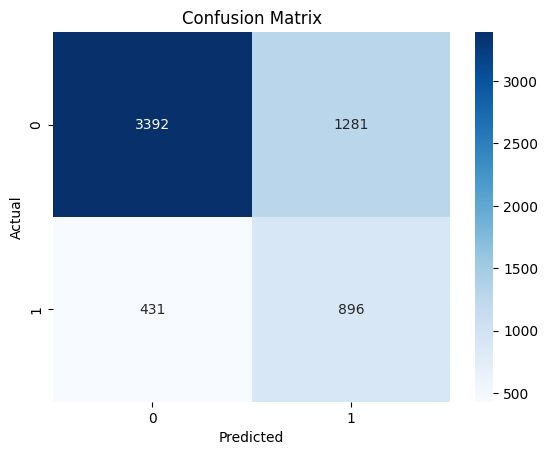

In [17]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.73      0.80      4673
           1       0.41      0.68      0.51      1327

    accuracy                           0.71      6000
   macro avg       0.65      0.70      0.65      6000
weighted avg       0.78      0.71      0.74      6000



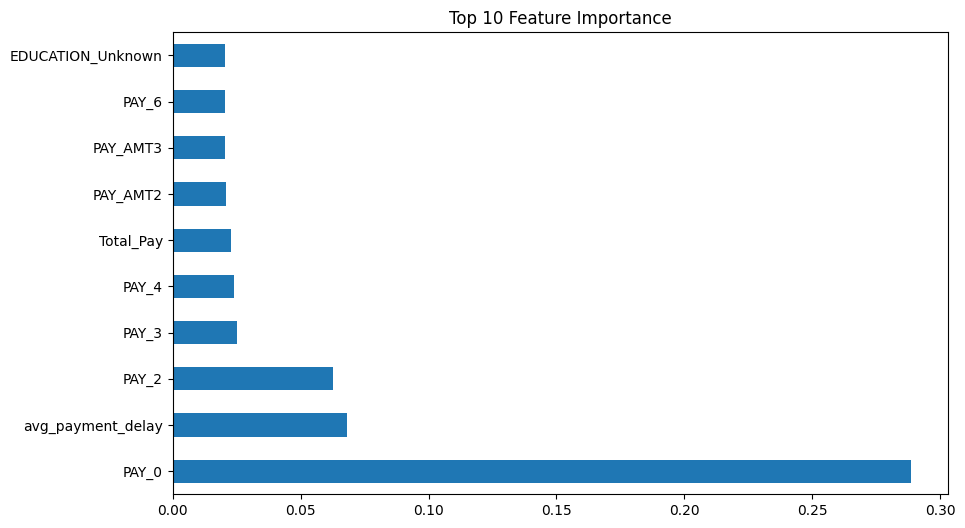

In [19]:
# Feature Importance

importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_features.plot(kind="barh")
plt.title("Top 10 Feature Importance")
plt.show()

In [20]:
# Calculate ROC AUC score
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.7728764918189132
